# **Imports**

In [1]:
!pip install pmdarima
!pip install git+https://github.com/scikit-learn-contrib/py-earth@v0.2dev

     |████████████████████████████████| 1.5 MB 4.0 MB/s 
     |████████████████████████████████| 9.5 MB 12.1 MB/s 
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.10.2
    Uninstalling statsmodels-0.10.2:
      Successfully uninstalled statsmodels-0.10.2
  Cloning https://github.com/scikit-learn-contrib/py-earth (to revision v0.2dev) to /tmp/pip-req-build-cz65_knp
  Running command git clone -q https://github.com/scikit-learn-contrib/py-earth /tmp/pip-req-build-cz65_knp
  Running command git checkout -b v0.2dev --track origin/v0.2dev
  Switched to a new branch 'v0.2dev'
  Branch 'v0.2dev' set up to track remote branch 'v0.2dev' from 'origin'.
  Created wheel for sklearn-contrib-py-earth: filename=sklearn_contrib_py_earth-0.1.0+16.g400f84d-cp37-cp37m-linux_x86_64.whl size=3997345 sha256=79b488f92d12f2238de64249d87f081ebe9491f01bba20f8b89385a231dfcc02
  Stored in directory: /tmp/pip-ephem-wheel-cache-eg4umq0m/wheels/79/d7/aa/1e418a9aea84424ef2ce2697ae7c

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import datetime
import warnings
import matplotlib.pyplot as plt
import statsmodels.api as sm
import math
import sklearn
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots  import plot_acf as pltacf
from  statsmodels.tsa.stattools import pacf as PACF
from statsmodels.graphics.tsaplots  import plot_pacf as pltpacf
from pmdarima.arima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
warnings.filterwarnings('ignore')

In [3]:
!gdown --id 1oYFmiJ-hKcXR9xKKZmgXlGzO8xlM2YY8

Downloading...
From: https://drive.google.com/uc?id=1oYFmiJ-hKcXR9xKKZmgXlGzO8xlM2YY8
To: /content/INFY.NS.csv
100% 157k/157k [00:00<00:00, 54.2MB/s]


In [4]:
stock_name="INFY"

In [5]:
df_stock = pd.read_csv('INFY.NS.csv',index_col='Date')
df_stock.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2016-01-01,550.000000,554.474976,546.599976,552.625000,1806550.0,4,1,1,7791.299805,7.875000
2016-01-04,549.974976,551.224976,538.025024,539.450012,3975362.0,0,4,1,7784.649902,13.199951
2016-01-05,542.750000,542.750000,531.125000,537.025024,4949786.0,1,5,1,7741.000000,11.625000
2016-01-06,537.325012,537.325012,529.450012,534.674988,5588328.0,2,6,1,7568.299805,7.875000
2016-01-07,530.025024,533.950012,523.950012,525.400024,5294088.0,3,7,1,7601.350098,10.000000


#**ARIMA - Autoregression Intergrated Moving Average**

##*Decomposing the data*

In [6]:
df_stock['Close'].head()

Date
2016-01-01    552.625000
2016-01-04    539.450012
2016-01-05    537.025024
2016-01-06    534.674988
2016-01-07    525.400024
Name: Close, dtype: float64

Text(0.5, 1.0, 'Close Price - INFY')

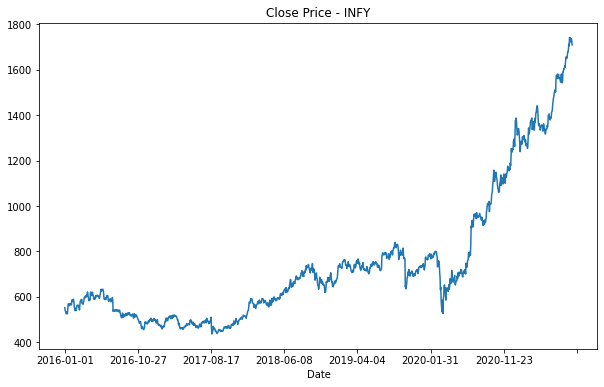

In [7]:
plt.rcParams['figure.figsize'] = (10,6)
df_stock['Close'].plot()
plt.title("Close Price - "+stock_name)

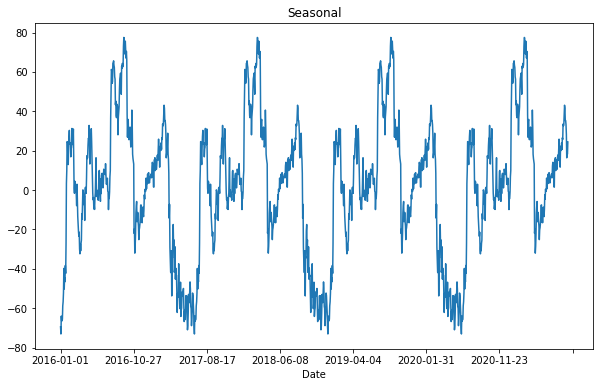

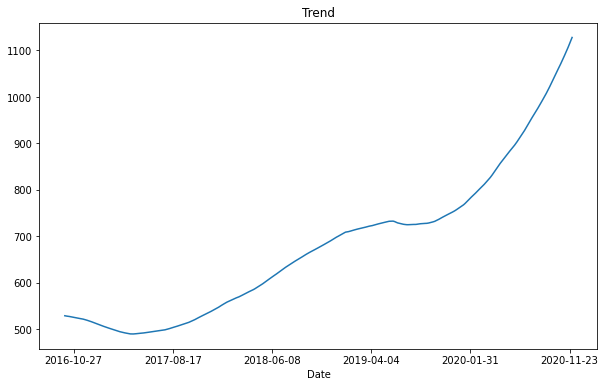

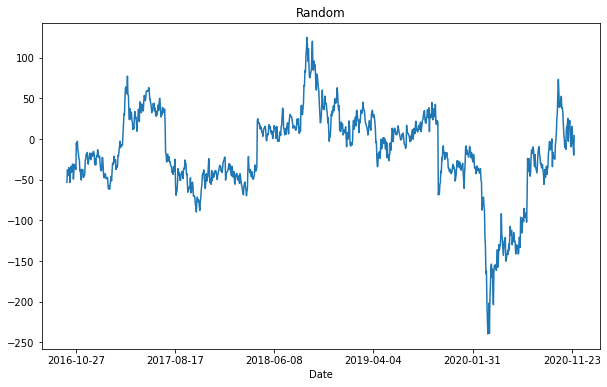

In [8]:
plt.rcParams['figure.figsize'] = (10,6)
decomposition=seasonal_decompose(df_stock['Close'],freq=365)
decomposition.seasonal.plot()
plt.title("Seasonal")
plt.show()
decomposition.trend.plot()
plt.title("Trend")
plt.show()
decomposition.resid.plot()
plt.title("Random")
plt.show()

##*Stationary Check*

In [9]:
Stationary=False
dvalue=0
Stationary_df=df_stock['Close'].copy()
while(Stationary==False):
  dftest = adfuller(Stationary_df.dropna(),autolag='AIC')
  dfoutput=pd.Series(dftest[0:4],index=['Test Statistic','p-value','#lags used','number of observations used'])
  for key,value in dftest[4].items():
    dfoutput['critical value (%s)'%key]= value
  print(dftest[1])
  if (dftest[1]>0.05):
    Stationary=False
    Stationary_df = Stationary_df - Stationary_df.shift(1)
  else :
    Stationary=True
  dvalue+=1  
print(dfoutput)
print("Differencing Value : ",dvalue)

0.9989992701257483
6.870089975077196e-26
Test Statistic                -1.385586e+01
p-value                        6.870090e-26
#lags used                     6.000000e+00
number of observations used    1.380000e+03
critical value (1%)           -3.435097e+00
critical value (5%)           -2.863637e+00
critical value (10%)          -2.567886e+00
dtype: float64
Differencing Value :  2


##*ACF*

In [10]:
from  statsmodels.tsa.stattools import acf as ACF
ACFOutput = ACF(Stationary_df.dropna(),nlags=20)
print(ACFOutput)

[ 1.         -0.01160346 -0.00987408  0.00437812 -0.02492824  0.05650119
 -0.07792703  0.05227861  0.01505622 -0.02146997 -0.02536056  0.00870126
  0.01564422  0.02657235 -0.01166403  0.01593891 -0.00947378 -0.01251034
  0.01811817 -0.02222871  0.07667386]


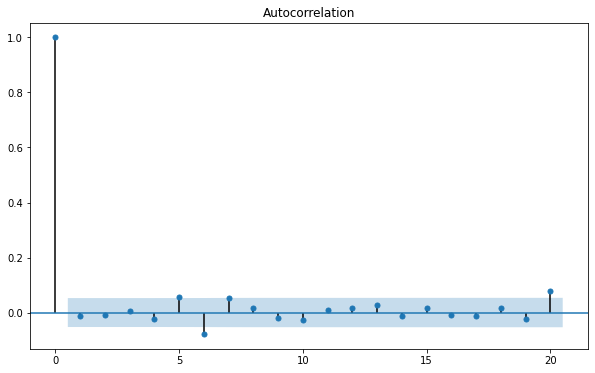

In [11]:
plt.rcParams['figure.figsize'] = (10,6)
pltacf(Stationary_df.dropna(),lags=20)
plt.show()

##*PACF*

In [12]:
PACFOutput = PACF(Stationary_df.dropna(),nlags=20)
print(PACFOutput)

[ 1.         -0.01161183 -0.01002453  0.00415622 -0.02500576  0.05625813
 -0.07787127  0.05320045  0.01282057 -0.01678082 -0.03332476  0.01966746
  0.00401262  0.03371754 -0.01171283  0.01665834 -0.01431594 -0.00584617
  0.01436547 -0.01842697  0.07131791]


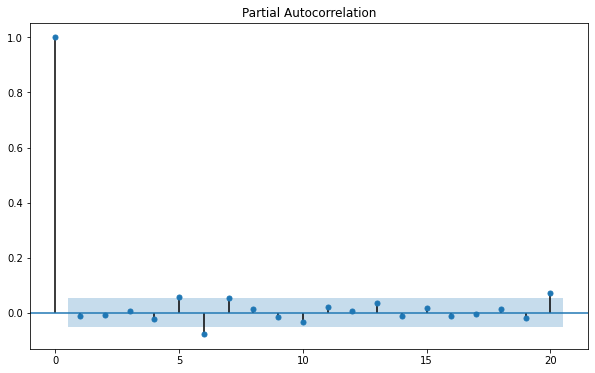

In [13]:
plt.rcParams['figure.figsize'] = (10,6)
pltpacf(Stationary_df.dropna(),lags=20).show()
plt.show()

##*Test and Train Split*

In [14]:
df_stock_train=df_stock.loc['2016-01-01':'2021-07-31']['Close']
df_stock_test=df_stock.loc['2021-07-31':]['Close']

In [15]:
df_stock_train.tail()

Date
2021-07-26    1603.900024
2021-07-27    1602.550049
2021-07-28    1605.599976
2021-07-29    1617.000000
2021-07-30    1610.500000
Name: Close, dtype: float64

In [16]:
df_stock_test.head()

Date
2021-08-02    1631.550049
2021-08-03    1655.199951
2021-08-04    1649.250000
2021-08-05    1653.550049
2021-08-06    1650.199951
Name: Close, dtype: float64

##*Model Fitting*

In [17]:
arima_model=auto_arima(df_stock_train,seasonal=False,max_p=2,max_d=2,max_q=2,start_p=0,start_q=0,d=1)

In [18]:
arima_model

ARIMA(maxiter=50, method='lbfgs', order=(0, 1, 0), out_of_sample_size=0,
      scoring='mse', scoring_args={}, seasonal_order=(0, 0, 0, 0),
      start_params=None, suppress_warnings=True, trend=None,
      with_intercept=True)

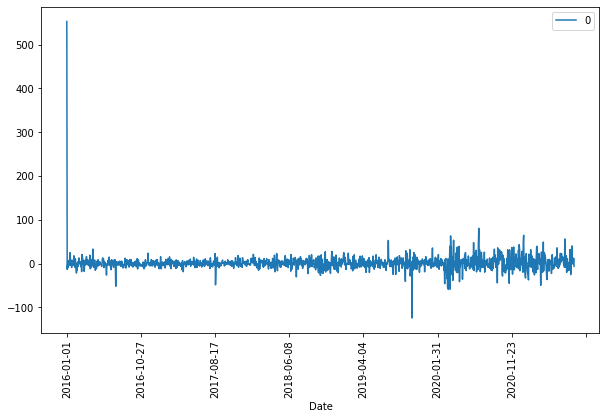

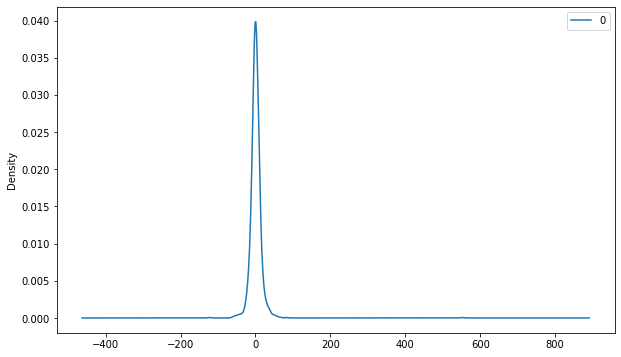

                 0
count  1369.000000
mean      1.189724
std      19.815683
min    -124.346018
25%      -5.151754
50%       0.441299
75%       6.717731
max     552.625000


In [19]:
model = ARIMA(df_stock_train, order=(1,1,1))
model_fit = model.fit()
residuals = pd.DataFrame(model_fit.resid)
plt.rcParams['figure.figsize'] = (10,6)
residuals.plot()
plt.xticks(rotation=90)
plt.show()
residuals.plot(kind='kde')
plt.show()
print(residuals.describe())

##*Forecasting and Testing*

In [20]:
history = [x for x in df_stock_train.values]
predictions = list()
for t in range(len(df_stock_test.values)):
    model = ARIMA(history, order=(1,1,1))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = df_stock_test.values[t]
    history.append(obs)
error = np.sqrt(mean_squared_error(df_stock_test.values, predictions))
print('Test Error Percentage',(error/np.mean(df_stock_test.values))*100)

Test Error Percentage 0.9177418688860562


([], <a list of 0 Text major ticklabel objects>)

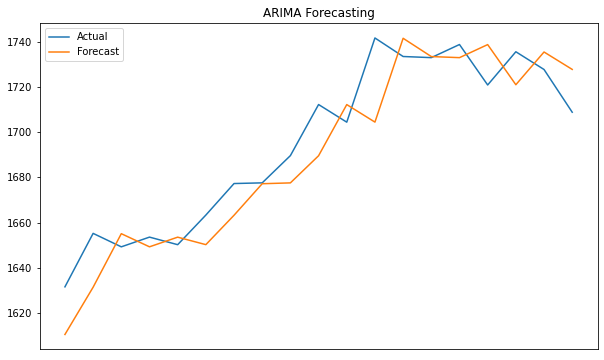

In [21]:
plt.rcParams['figure.figsize'] = (10,6)
plt.plot(df_stock_test, label='Actual')
plt.plot(predictions, label='Forecast')
plt.title('ARIMA Forecasting')
plt.legend()
plt.xticks([])

##*Forecast for August*

In [22]:
history = [x for x in df_stock_train.values]
predictions = list()
for t in range(len(df_stock_test.values[:14])):
    model = ARIMA(history, order=(1,1,1))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = df_stock_test.values[t]
    history.append(obs)

In [23]:
predictions

[1610.4775115781056,
 1631.38424718468,
 1655.0673025528686,
 1649.259200889648,
 1653.527076717075,
 1650.2158274526719,
 1663.218807351595,
 1677.1685617941257,
 1677.5374070149899,
 1689.5439113400446,
 1712.1808302287372,
 1704.4262030648677,
 1741.5095774499855,
 1733.4211814596194]

#**MARS - Multivariate Adaptive Regression Splines**

In [24]:
from pyearth import Earth

In [25]:
df_stock_mars_train=df_stock.loc['2016-01-01':'2021-07-31'].iloc[:,:5].copy()
df_stock_mars_test=df_stock.loc['2021-07-31':].iloc[:,:5].copy()

In [26]:
df_stock_mars_train.shape

(1369, 5)

In [27]:
df_stock_mars_test.shape

(19, 5)

In [28]:
df_stock_mars_train.head()

,Open,High,Low,Close,Volume
Date,,,,,
2016-01-01,550.000000,554.474976,546.599976,552.625000,1806550.0
2016-01-04,549.974976,551.224976,538.025024,539.450012,3975362.0
2016-01-05,542.750000,542.750000,531.125000,537.025024,4949786.0
2016-01-06,537.325012,537.325012,529.450012,534.674988,5588328.0
2016-01-07,530.025024,533.950012,523.950012,525.400024,5294088.0


In [29]:
df_stock_mars_test

,Open,High,Low,Close,Volume
Date,,,,,
2021-08-02,1627.449951,1634.750000,1619.199951,1631.550049,5553389.0
2021-08-03,1647.000000,1658.650024,1635.599976,1655.199951,5513668.0
2021-08-04,1669.099976,1679.900024,1639.050049,1649.250000,6740391.0
2021-08-05,1649.500000,1666.000000,1647.050049,1653.550049,5420536.0
2021-08-06,1657.000000,1660.650024,1644.000000,1650.199951,3754855.0
2021-08-09,1661.000000,1667.449951,1646.400024,1663.300049,5018477.0
2021-08-10,1668.000000,1680.000000,1661.050049,1677.250000,6846517.0
2021-08-11,1674.800049,1684.000000,1668.000000,1677.550049,4899639.0
2021-08-12,1679.150024,1696.500000,1674.000000,1689.599976,5659579.0


In [30]:
x_train_mars = df_stock_mars_train.drop(['Close'], axis=1)
y_train_mars = df_stock_mars_train['Close']
x_test_mars = df_stock_mars_test.drop(['Close'], axis=1)
y_test_mars = df_stock_mars_test['Close']

##*Fitting the model*

In [31]:
MARS_model = Earth(max_terms = 600,max_degree=3)
MARS_model_fitted = MARS_model.fit(x_train_mars, y_train_mars)
y_pred_mars = MARS_model_fitted.predict(x_test_mars[:14])

##*Evaluating the model*

In [32]:
MSE = mean_squared_error(y_test_mars[:14], y_pred_mars)
RMSE = np.sqrt(MSE)
RMSE_mean = (RMSE/np.mean(y_test_mars[:14]))*100
print("RMSE Score :", round(RMSE, 2))
print("RMSE/Mean", round(RMSE_mean,1))

RMSE Score : 8.2
RMSE/Mean 0.5


##*Plotting Forecast vs Actual* 

([], <a list of 0 Text major ticklabel objects>)

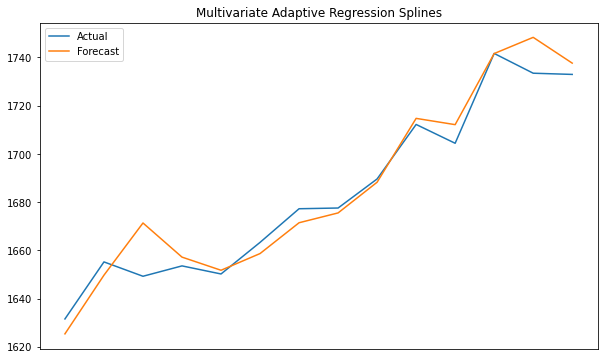

In [33]:
plt.rcParams['figure.figsize'] = (10,6)
plt.plot(y_test_mars[:14], label='Actual')
plt.plot(y_pred_mars, label='Forecast')
plt.title('Multivariate Adaptive Regression Splines')
plt.legend()
plt.xticks([])

#**VAR - Vector Autoregression**

In [34]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tools.eval_measures import rmse, aic

In [35]:
df_stock_var = df_stock.loc['2016-01-01':'2021-08-20'].iloc[:,:4].copy()
df_stock_var_train=df_stock.loc['2016-01-01':'2021-07-31'].iloc[:,:4].copy()
df_stock_var_test=df_stock.loc['2021-07-31':'2021-08-20'].iloc[:,:4].copy()


In [36]:
df_stock_var_train.shape

(1369, 4)

In [37]:
df_stock_var_test.shape

(14, 4)

In [38]:
df_stock_var.shape

(1383, 4)

##*Plotting the Data*

In [39]:
fig, axes = plt.subplots(nrows=4, ncols=1, dpi=120, figsize=(10,6))
for i, ax in enumerate(axes.flatten()):
    data = df_stock_var[df_stock_var.columns[i]]
    ax.plot(data, linewidth=1)
    # Decorations
    ax.set_title(df_stock_var.columns[i])
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines["top"].set_alpha(0)
    ax.tick_params(labelsize=6)

plt.tight_layout()

##*Granger Causality Test*

In [40]:
from statsmodels.tsa.stattools import grangercausalitytests
maxlag=12
test = 'ssr_chi2test'
def grangers_causation_matrix(data, variables, test='ssr_chi2test', verbose=False):    
    df = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for c in df.columns:
        for r in df.index:
            test_result = grangercausalitytests(data[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [round(test_result[i+1][0][test][1],4) for i in range(maxlag)]
            if verbose: print(f'Y = {r}, X = {c}, P Values = {p_values}')
            min_p_value = np.min(p_values)
            df.loc[r, c] = min_p_value
    df.columns = [var + '_x' for var in variables]
    df.index = [var + '_y' for var in variables]
    return df

grangers_causation_matrix(df_stock_var, variables = df_stock_var.columns)        

,Open_x,High_x,Low_x,Close_x
Open_y,1.0000,0.0000,0.0,0.0
High_y,0.0079,1.0000,0.0,0.0
Low_y,0.0000,0.0000,1.0,0.0
Close_y,0.0002,0.0661,0.0,1.0


##*Cointegration Test*

In [41]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

def cointegration_test(df_stock_var, alpha=0.05): 
    out = coint_johansen(df_stock_var,-1,5)
    d = {'0.90':0, '0.95':1, '0.99':2}
    traces = out.lr1
    cvts = out.cvt[:, d[str(1-alpha)]]
    def adjust(val, length= 6): return str(val).ljust(length)

    print('Name   ::  Test Statistic > C(95%)    =>   Significance  \n', '--'*20)
    for col, trace, cvt in zip(df_stock_var.columns, traces, cvts):
        print(adjust(col), ':: ', adjust(round(trace,2), 9), ">", adjust(cvt, 8), ' =>  ' , trace > cvt)

cointegration_test(df_stock_var)

Name   ::  Test Statistic > C(95%)    =>   Significance  
 ----------------------------------------
Open   ::  529.26    > 40.1749   =>   True
High   ::  275.64    > 24.2761   =>   True
Low    ::  83.17     > 12.3212   =>   True
Close  ::  11.33     > 4.1296    =>   True


##*ADF Test*

In [42]:
def adfuller_test(series, signif=0.05, name='', verbose=False):
    """Perform ADFuller to test for Stationarity of given series and print report"""
    r = adfuller(series, autolag='AIC')
    output = {'test_statistic':round(r[0], 4), 'pvalue':round(r[1], 4), 'n_lags':round(r[2], 4), 'n_obs':r[3]}
    p_value = output['pvalue'] 
    def adjust(val, length= 6): return str(val).ljust(length)

    # Print Summary
    print(f'    Augmented Dickey-Fuller Test on "{name}"', "\n   ", '-'*47)
    print(f' Null Hypothesis: Data has unit root. Non-Stationary.')
    print(f' Significance Level    = {signif}')
    print(f' Test Statistic        = {output["test_statistic"]}')
    print(f' No. Lags Chosen       = {output["n_lags"]}')

    for key,val in r[4].items():
        print(f' Critical value {adjust(key)} = {round(val, 3)}')

    if p_value <= signif:
        print(f" => P-Value = {p_value}. Rejecting Null Hypothesis.")
        print(f" => Series is Stationary.")
    else:
        print(f" => P-Value = {p_value}. Weak evidence to reject the Null Hypothesis.")
        print(f" => Series is Non-Stationary.")    

In [43]:
# ADF Test on each column
for name, column in df_stock_var_train.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "Open" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = 1.8752
 No. Lags Chosen       = 20
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.9985. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "High" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = 2.2947
 No. Lags Chosen       = 9
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.999. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "Low" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root.

##*ADF Test on first order differencing*

In [44]:
df_differenced = df_stock_var_train.diff().dropna()

In [45]:
# ADF Test on each column of 1st Differences Dataframe
for name, column in df_differenced.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "Open" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -7.4609
 No. Lags Chosen       = 19
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "High" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -12.586
 No. Lags Chosen       = 8
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "Low" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05


##*Selecting the number of lags*

In [46]:
model = VAR(df_differenced)
x = model.select_order(maxlags=20)
x.summary()

,AIC,BIC,FPE,HQIC
0,17.37,17.39,3.512e+07,17.38
1,16.03,16.10,9.132e+06,16.06
2,15.66,15.80,6.342e+06,15.71
3,15.48,15.68,5.292e+06,15.56
4,15.33,15.59,4.551e+06,15.43
5,15.21,15.53,4.018e+06,15.33
6,15.14,15.52*,3.752e+06,15.28
7,15.10,15.55,3.623e+06,15.27*
8,15.08,15.59,3.559e+06,15.28
9,15.06,15.63,3.466e+06,15.27


##*Fitting the model*

In [47]:
model_fitted = model.fit(x.aic)
model_fitted.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 15, Sep, 2021
Time:                     12:33:19
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    15.9169
Nobs:                     1353.00    HQIC:                   15.3292
Log likelihood:          -17567.5    FPE:                3.19656e+06
AIC:                      14.9773    Det(Omega_mle):     2.67964e+06
--------------------------------------------------------------------
Results for equation Open
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const             0.224215         0.207736            1.079           0.280
L1.Open          -1.030176         0.048236          -21.357           0.000
L1.High           0.105431         0.048104            2.192           0.028


##*Durbin Watson Test*

In [48]:
from statsmodels.stats.stattools import durbin_watson
out = durbin_watson(model_fitted.resid)

for col, val in zip(df_stock_var.columns, out):
    print(col, ':', round(val, 2))

Open : 2.0
High : 1.99
Low : 2.0
Close : 1.99


##*Getting the Forecast*

In [49]:
# Get the lag order
lag_order = model_fitted.k_ar
print(lag_order)

# Input data for forecasting
forecast_input = df_differenced.values[-lag_order:]
forecast_input

15


array([[-12.        ,  -6.09997559,   2.        ,   2.15002441],
       [ 14.55004883,   8.09997559, -17.25      , -15.05004883],
       [-14.15002441, -21.59997559,   2.55004883,  -2.90002441],
       [ -2.40002441,  26.40002441,   1.79992676,  31.95007324],
       [  3.90002441,  14.04992676,  17.90002441,   3.90002441],
       [ 15.84997559, -22.19995117,  -6.40002441, -25.35009766],
       [-29.05004883, -21.75      , -12.04992676, -13.75      ],
       [ -6.39990234,   4.79992676,   0.44995117,   8.35009766],
       [ 23.09997559,  35.15002441,  23.40002441,  40.14990234],
       [ 27.15002441,   5.65002441,  23.65002441,   0.25      ],
       [  5.54992676,  13.15002441,   9.04992676,  13.45007324],
       [ 10.90002441,  -2.34997559,   3.80004883,  -1.34997559],
       [  0.09997559,  -1.70007324, -12.40002441,   3.04992676],
       [ -5.        ,  12.40002441,  14.59997559,  11.40002441],
       [  9.90002441,   3.40002441,   6.05004883,  -6.5       ]])

In [50]:
nobs = 14
fc = model_fitted.forecast(y=forecast_input, steps=nobs)
df_forecast = pd.DataFrame(fc, index=df_stock_var.index[-nobs:], columns=df_stock_var.columns + '_1d')
df_forecast

,Open_1d,High_1d,Low_1d,Close_1d
Date,,,,
2021-08-02,3.148606,4.713950,0.775478,9.735429
2021-08-03,8.547070,1.850272,1.433553,-2.086364
2021-08-04,-1.326119,2.057102,2.652072,7.696852
2021-08-05,3.534841,-0.626190,-0.489985,-6.736480
2021-08-06,-13.211076,-6.542242,-8.522575,-3.918780
2021-08-09,2.667685,0.751194,3.027722,3.547173
2021-08-10,4.735686,3.420636,2.304877,-0.475648
2021-08-11,-3.368840,-1.841912,-1.657341,-0.030017
2021-08-12,-0.424984,-0.983404,-1.313611,-2.210182


##*Inverting forecast back to original scale*

In [51]:
def invert_transformation(df_train, df_forecast, first_diff=False):
    """Revert back the differencing to get the forecast to original scale."""
    df_fc = df_forecast.copy()
    columns = df_train.columns
    for col in columns:        
        if first_diff:
          # Roll back 1st Diff
          df_fc[str(col)+'_forecast'] = df_train[col].iloc[-1] + df_fc[str(col)+'_1d'].cumsum()
    return df_fc

In [52]:
df_results = invert_transformation(df_stock_var_train, df_forecast, first_diff=True)        
df_results.loc[:, ['Open_forecast','High_forecast','Low_forecast','Close_forecast']]

,Open_forecast,High_forecast,Low_forecast,Close_forecast
Date,,,,
2021-08-02,1613.148606,1628.113975,1606.925502,1620.235429
2021-08-03,1621.695676,1629.964247,1608.359056,1618.149065
2021-08-04,1620.369557,1632.021349,1611.011128,1625.845917
2021-08-05,1623.904398,1631.395159,1610.521143,1619.109437
2021-08-06,1610.693322,1624.852917,1601.998568,1615.190658
2021-08-09,1613.361006,1625.604111,1605.026290,1618.737831
2021-08-10,1618.096692,1629.024747,1607.331167,1618.262183
2021-08-11,1614.727852,1627.182835,1605.673826,1618.232166
2021-08-12,1614.302868,1626.199431,1604.360215,1616.021984


##*Plotting Forecast vs Actual*

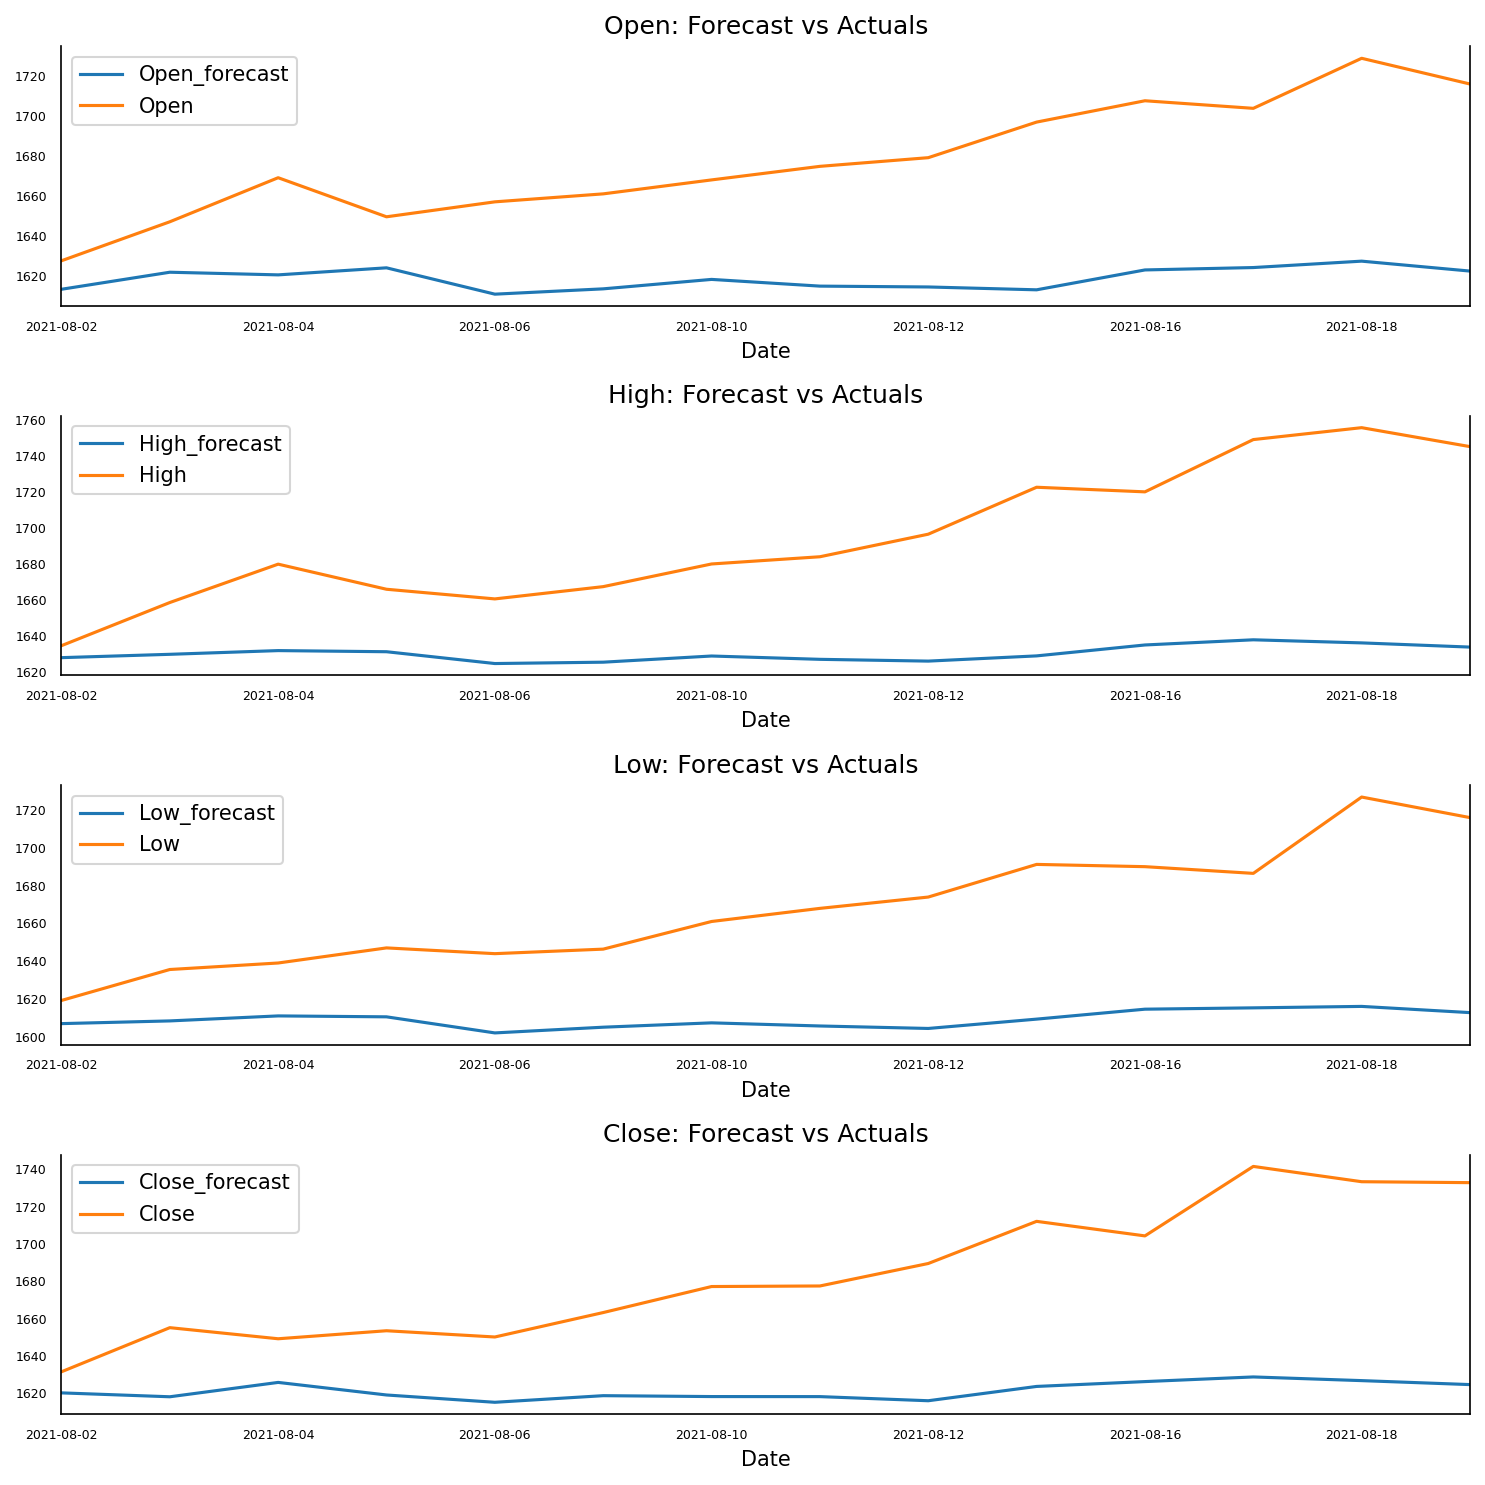

In [53]:
 fig, axes = plt.subplots(nrows=4, ncols=1, dpi=150, figsize=(10,10))
 for i, (col,ax) in enumerate(zip(df_stock_var.columns, axes.flatten())):
   df_results[col+'_forecast'].plot(legend=True, ax=ax).autoscale(axis='x',tight=True)
   df_stock_var_test[col][-nobs:].plot(legend=True, ax=ax);
   ax.set_title(col + ": Forecast vs Actuals")
   ax.xaxis.set_ticks_position('none')
   ax.yaxis.set_ticks_position('none')
   ax.spines["top"].set_alpha(0)
   ax.tick_params(labelsize=6)

plt.tight_layout();

##*Evaluating the model*

In [54]:
from statsmodels.tsa.stattools import acf
def forecast_accuracy(forecast, actual): 
    rmse = np.mean((forecast - actual)**2)**.5  
    rmse_p = (rmse/np.mean(actual))*100
    return({'rmse':rmse,'rmse_mean':rmse_p})

print('Forecast Accuracy of Open')
accuracy_prod = forecast_accuracy(df_results['Open_forecast'].values, df_stock_var_test['Open'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of High')
accuracy_prod = forecast_accuracy(df_results['High_forecast'].values, df_stock_var_test['High'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of Low')
accuracy_prod = forecast_accuracy(df_results['Low_forecast'].values, df_stock_var_test['Low'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of Close')
accuracy_prod = forecast_accuracy(df_results['Close_forecast'].values, df_stock_var_test['Close'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))



Forecast Accuracy of Open
rmse :  64.5888
rmse_mean :  3.85

Forecast Accuracy of High
rmse :  72.1678
rmse_mean :  4.2595

Forecast Accuracy of Low
rmse :  64.7
rmse_mean :  3.88

Forecast Accuracy of Close
rmse :  70.0145
rmse_mean :  4.1583


#**Linear Regression**

In [55]:
df_stock_train_lin=df_stock.loc['2016-01-01':'2021-07-31'].copy()
df_stock_test_lin=df_stock.loc['2021-07-31':].copy()


##*Normalize the data*

In [56]:
from sklearn.preprocessing import MinMaxScaler

In [57]:
scaler = MinMaxScaler()
df_stock_train_lin[['Open', 'High','Low','Volume','NIFTY50','Range']] = scaler.fit_transform(df_stock_train_lin[['Open', 'High','Low','Volume','NIFTY50','Range']])
df_stock_test_lin[['Open', 'High','Low','Volume','NIFTY50','Range']] = scaler.transform(df_stock_test_lin[['Open', 'High','Low','Volume','NIFTY50','Range']])

In [58]:
df_stock_train_lin.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2016-01-01,0.094017,0.093824,0.099137,552.625000,0.006402,4,1,1,0.091661,0.052114
2016-01-04,0.093996,0.091069,0.091846,539.450012,0.019655,0,4,1,0.090919,0.108747
2016-01-05,0.087821,0.083884,0.085980,537.025024,0.025609,1,5,1,0.086044,0.091997
2016-01-06,0.083184,0.079285,0.084556,534.674988,0.029511,2,6,1,0.066755,0.052114
2016-01-07,0.076944,0.076424,0.079879,525.400024,0.027713,3,7,1,0.070447,0.074714


In [59]:
df_stock_test_lin.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2021-08-02,1.014914,1.009622,1.011095,1631.550049,0.029298,0,2,8,1.023069,0.133741
2021-08-03,1.031624,1.029883,1.025039,1655.199951,0.029055,1,3,8,1.037370,0.213508
2021-08-04,1.050513,1.047898,1.027973,1649.250000,0.036551,2,4,8,1.041369,0.402818
2021-08-05,1.033761,1.036114,1.034774,1653.550049,0.028486,3,5,8,1.035070,0.169901
2021-08-06,1.040171,1.031579,1.032181,1650.199951,0.018307,4,6,8,1.037309,0.145440


##*Checking for multicollinearity*

In [60]:
from statsmodels.stats.outliers_influence import variance_inflation_factor    

def calculate_vif_(X, thresh=10,verbose=True):
    cols = X.columns
    variables = np.arange(X.shape[1])
    dropped=True
    while dropped:
        dropped=False
        c = X[cols[variables]].values
        vif = [variance_inflation_factor(c, ix) for ix in np.arange(c.shape[1])]
        

        maxloc = vif.index(max(vif))
        if max(vif) > thresh:
            if verbose == True:
                print('dropping \'' + X[cols[variables]].columns[maxloc] + '\' at index: ' + str(maxloc))
            variables = np.delete(variables, maxloc)
            dropped=True
    if verbose == True:
        print('Remaining variables:')
        print(X.columns[variables])
    return X[cols[variables]]

##*Model Generation*

In [61]:
def forward_regression(X, y,
                       threshold_in,
                       verbose=False):
    initial_list = []
    included = list(initial_list)
    while True:
        changed=False
        excluded = list(set(X.columns)-set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included+[new_column]]))).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed=True
            if verbose:
                print('Add  {:30} with p-value {:.6}'.format(best_feature, best_pval))

        if not changed:
            break

    return included

In [62]:
def backward_regression(X, y,
                           threshold_out,
                           verbose=False):
    included=list(X.columns)
    while True:
        changed=False
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max() 
        if worst_pval > threshold_out:
            changed=True
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            if verbose:
                print('Drop {:30} with p-value {:.6}'.format(worst_feature, worst_pval))
        if not changed:
            break
    return included

In [63]:
def model_generator(df_train,df_test):
    train_dummy=pd.get_dummies(df_train,columns=['Day of Week','Day of Month','Month'])
    test_dummy = pd.get_dummies(df_test,columns=['Day of Week','Day of Month','Month'])
    for i in [1,2,3,4,5,6,7,9,10,11,12]:
        test_dummy['Month_'+str(i)] = 0
        test_dummy['Month_'+str(i)] = test_dummy['Month_'+str(i)].astype('uint8')
    for i in range(1,32):
      if (i not in df_test['Day of Month'].unique()):
        test_dummy['Day of Month_'+str(i)] = 0
        test_dummy['Day of Month_'+str(i)] = test_dummy['Day of Month_'+str(i)].astype('uint8')   
    X=train_dummy.drop('Close',axis=1)
    y=train_dummy["Close"]
    X_f=calculate_vif_(X.select_dtypes(exclude='uint8'),10,False)
    X_f=pd.concat([X_f,X.iloc[:,6:]],axis=1)
    model=sm.OLS(y,X_f[backward_regression(X_f,y,0.01)],axis=1).fit()
    pred=model.predict(test_dummy[backward_regression(X_f,y,0.01)])
    rmse = math.sqrt(sklearn.metrics.mean_squared_error(test_dummy['Close'], pred))
    rmse_pct= (rmse/np.mean(test_dummy['Close']))*100
    sig_var = model.pvalues.index.tolist()
    return model,sig_var,rmse_pct    

In [64]:
 model,variables,rmse_per = model_generator(df_stock_train_lin,df_stock_test_lin)

In [65]:
print(model.summary2())

                   Results: Ordinary least squares
Model:               OLS               Adj. R-squared:      0.998     
Dependent Variable:  Close             AIC:                 10464.3666
Date:                2021-09-15 12:33  BIC:                 10725.4584
No. Observations:    1369              Log-Likelihood:      -5182.2   
Df Model:            49                F-statistic:         1.811e+04 
Df Residuals:        1319              Prob (F-statistic):  0.00      
R-squared:           0.999             Scale:               117.93    
----------------------------------------------------------------------
                  Coef.   Std.Err.    t     P>|t|    [0.025    0.975] 
----------------------------------------------------------------------
Open            1159.8142   2.9549 392.5105 0.0000 1154.0174 1165.6109
Volume           -28.3655   7.5463  -3.7589 0.0002  -43.1695  -13.5614
NIFTY50            7.7704   2.7521   2.8234 0.0048    2.3714   13.1693
Range             12.4802 

In [66]:
print("Significance Variables :",'\n',*variables,sep='\n')

Significance Variables :


Open
Volume
NIFTY50
Range
Day of Week_0
Day of Week_1
Day of Week_2
Day of Week_3
Day of Week_4
Day of Month_1
Day of Month_2
Day of Month_3
Day of Month_4
Day of Month_5
Day of Month_6
Day of Month_7
Day of Month_8
Day of Month_9
Day of Month_10
Day of Month_11
Day of Month_12
Day of Month_13
Day of Month_14
Day of Month_15
Day of Month_16
Day of Month_17
Day of Month_18
Day of Month_19
Day of Month_20
Day of Month_21
Day of Month_22
Day of Month_23
Day of Month_24
Day of Month_25
Day of Month_26
Day of Month_27
Day of Month_28
Day of Month_29
Day of Month_30
Day of Month_31
Month_1
Month_2
Month_3
Month_4
Month_5
Month_6
Month_7
Month_8
Month_9
Month_10
Month_11
Month_12


In [67]:
print("RMSE Percentage",rmse_per,sep='\n')

RMSE Percentage
0.9200438422288822
